# Overview

## Create the simulation

In [ ]:
import numpy as np
from lucifex.io import write
from lucifex.fem import resample_grid, as_grid_function
from lucifex.sim import run, xdmf_to_npz
from lucifex.plt import (
    plot_colormap, plot_contours, create_multifigure, plot_colormap_multifigure,
    get_ipynb_file_name, set_ipynb_variable, save_figure,
)
from lucifex.utils.npy_utils import as_index
from crocodil.theory.system_a import threshold_rayleigh
from crocodil.dns.system_c import dns_system_c, plot_gravity_arrow, SYSTEM_C_REFERENCE

STORE = 1
WRITE = None
DIR_ROOT = f'./figures/{get_ipynb_file_name()}'
NX = set_ipynb_variable('NX', 100)
NY = set_ipynb_variable('NY', 100)
ANIM = set_ipynb_variable('ANIM', False)

simulation = dns_system_c(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_root=DIR_ROOT, 

    dir_uid=True,
)(
    Nx=NX,
    Ny=NY,
    cell='quadrilateral',
    scaling='advective',
    **SYSTEM_C_REFERENCE,
    dt_Cu=0.75,
    dt_Cd=0.75,
    dt_Cr=0.1,
    c_stabilization=None,
    c_limits=True,
    diagnostic=True,
)

Lx, Ly = simulation['Lx', 'Ly']
Ra, Da, epsilon, beta, eta0, sr, cr = (
    float(i) for i in simulation['Ra', 'Da', 'epsilon', 'beta', 'eta0', 'sr', 'cr']
)

Ra_thresh = threshold_rayleigh(Lx, Ly, NX, 2)
print(f"Ra = {Ra} , Ra_thresh = {Ra_thresh}")

Ra = 1000.0 , Ra_thresh = 2250.0


## Run the simulation

In [ ]:
n_stop = set_ipynb_variable('N_STOP', 200)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

run(simulation, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
if WRITE: 
    xdmf_to_npz(simulation, delete_xdmf=False)
else:
    write(simulation.parameters, simulation.parameter_file, simulation.dir_path, mode='w')

s, c, psi, u = simulation['s', 'c', 'psi', 'u']
mC, mD = simulation['mC', 'mD']

  0%|          | 0/200 [00:00<?, ?it/s]

## Visualization

### Concentration and saturation

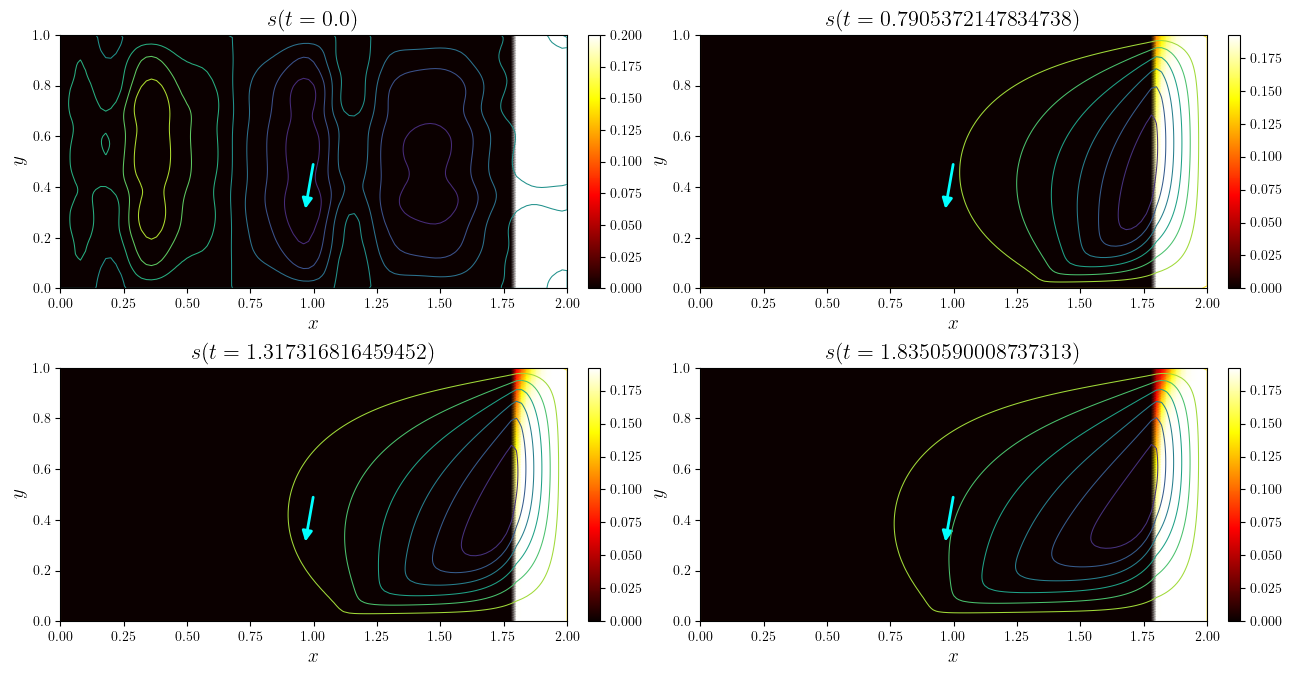

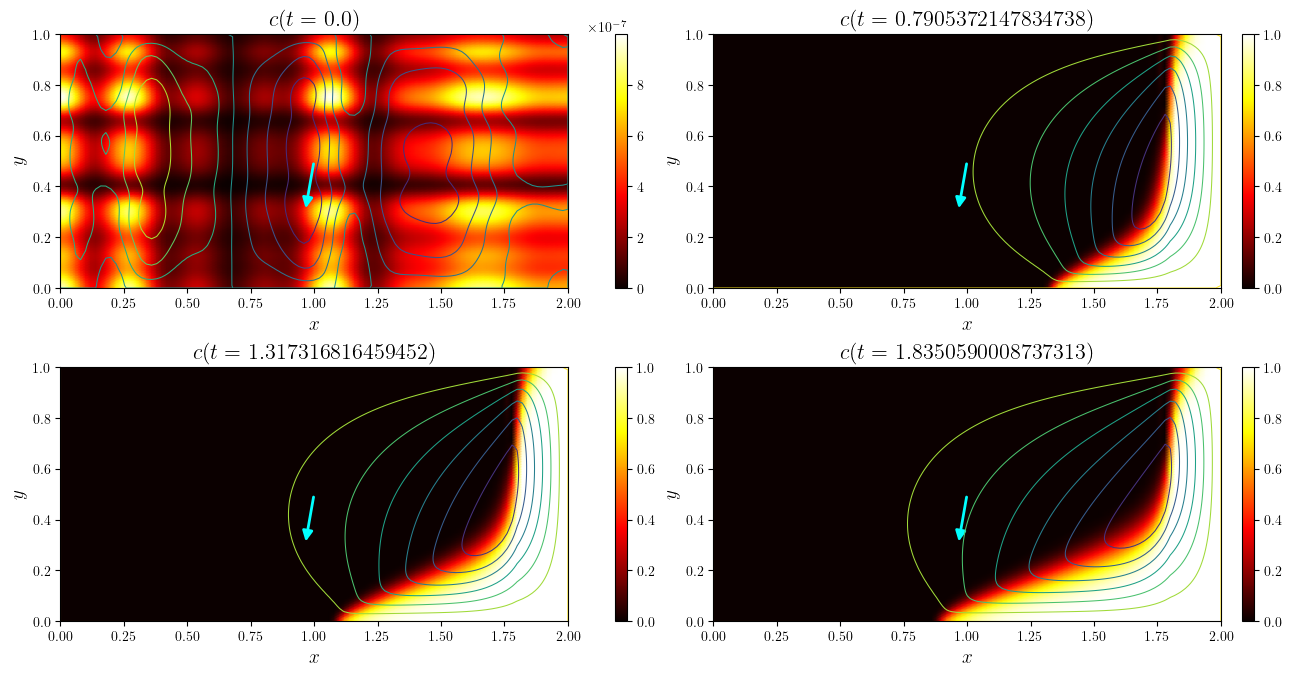

In [ ]:
contours = True
gravity = True
time_indices = as_index(c.time_series, (0, 0.5, 0.75, -1), fraction=True)

for w in (s, c):
    mfig, axs, _ = plot_colormap_multifigure(n_cols=2, cbars=True)(
        [w.series[i] for i in time_indices],
        title=[f'${w.name}(t={w.time_series[i]})$' for i in time_indices],
    )
    if contours:
        for ax, i in zip(axs, time_indices):
            plot_contours(mfig, ax, psi.series[i], cmap='viridis')
    if gravity is True:
        for ax in axs:
            plot_gravity_arrow(ax, 0.5 * np.array((Lx, Ly)), 0.2, beta)

## Thumnail image

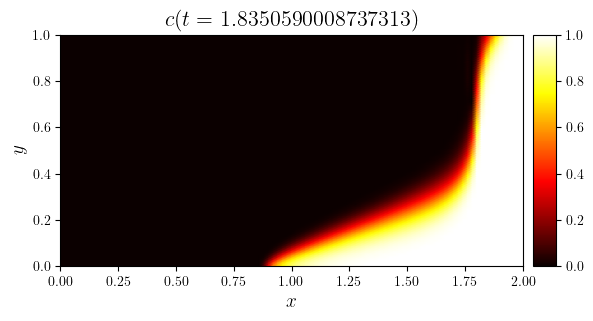

: 

In [ ]:
time_index = -1
fig, ax = plot_colormap(c.series[time_index], title=f'$c(t={c.time_series[time_index]})$')
save_figure('thumbnail', DIR_ROOT, prefix=False)(fig, file_ext='png')